# Dataset Exploration: Moltbook vs. Reddit

This notebook provides an interactive environment to load the parsed NetworkX graphs for both platforms and run basic statistical analyses.

In [4]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import cumfreq


# Import our loading functions
from utils import load_moltbook_graph, load_reddit_graph, get_platform_colors

plt.style.use('default')
plt.rcParams.update({'font.size': 16})

## 1. Load the Datasets

This cell will parse the Hugging Face datasets and build the NetworkX `DiGraph` objects if they haven't been cached already. (Note: The first run may take a little while for Reddit depending on the `limit` parameter, but subsequent runs will load instantly from the `.pkl` caches).

In [10]:
# Load Moltbook
print("Loading Moltbook Graph...")
G_moltbook = load_moltbook_graph(cache=True)
print(f"Moltbook Nodes: {G_moltbook.number_of_nodes():,}")
print(f"Moltbook Edges: {G_moltbook.number_of_edges():,}\n")

# Load Reddit
print("Loading Reddit Graph...")
G_reddit = load_reddit_graph(cache=True, limit=150000)
print(f"Reddit Nodes: {G_reddit.number_of_nodes():,}")
print(f"Reddit Edges: {G_reddit.number_of_edges():,}")

2026-04-07 10:34:49,344 - INFO - Loading Moltbook graph from cache: c:\Users\malda\Documents\Moltbook-Analysis\data\cache_moltbook_graph.pkl
2026-04-07 10:34:49,525 - INFO - Building Reddit graph from Hugging Face dataset (limit=150000)...


Loading Moltbook Graph...
Moltbook Nodes: 9,694
Moltbook Edges: 59,320

Loading Reddit Graph...


2026-04-07 10:34:49,804 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/anhchanghoangsg/reddit_pushshift_dataset_cleaned/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-04-07 10:34:49,830 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/anhchanghoangsg/reddit_pushshift_dataset_cleaned/e38d35ec3ccc6e3944a0c2ef68887b87e382558e/README.md "HTTP/1.1 200 OK"
2026-04-07 10:34:49,876 - INFO - HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/anhchanghoangsg/reddit_pushshift_dataset_cleaned/e38d35ec3ccc6e3944a0c2ef68887b87e382558e/README.md "HTTP/1.1 200 OK"
c:\Users\malda\anaconda3\envs\moltbook_rf\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\malda\.cache\huggingface\hub\datasets--anhchanghoangsg--reddit_pushshift_dataset_cleaned. Caching files will still 

Reddit Nodes: 6,893
Reddit Edges: 57,189


## 2. Basic Network Statistics

Let's look at some foundational metrics: Density, Average Degree, and the size of the Largest Weakly Connected Component (WCC).

In [11]:
def basic_stats(G):
    degrees = [d for n, d in G.degree()]
    in_degrees = [d for n, d in G.in_degree()]
    out_degrees = [d for n, d in G.out_degree()]
    
    wcc = max(nx.weakly_connected_components(G), key=len)
    
    print(f"--- {G.name} Stats ---")
    print(f"Density: {nx.density(G):.6f}")
    print(f"Avg Total Degree: {np.mean(degrees):.2f}")
    print(f"Avg In-Degree: {np.mean(in_degrees):.2f}")
    print(f"Avg Out-Degree: {np.mean(out_degrees):.2f}")
    print(f"Max Total Degree: {np.max(degrees)}")
    print(f"LCC Size: {len(wcc):,} nodes ({(len(wcc)/G.number_of_nodes()*100):.1f}% of network)\n")

basic_stats(G_moltbook)
basic_stats(G_reddit)

--- Moltbook Stats ---
Density: 0.000631
Avg Total Degree: 12.24
Avg In-Degree: 6.12
Avg Out-Degree: 6.12
Max Total Degree: 991
LCC Size: 9,446 nodes (97.4% of network)

--- Reddit Stats ---
Density: 0.001204
Avg Total Degree: 16.59
Avg In-Degree: 8.30
Avg Out-Degree: 8.30
Max Total Degree: 924
LCC Size: 6,837 nodes (99.2% of network)



## 3. Degree Distribution Analysis

Social networks typically follow a power-law (heavy-tailed) degree distribution. Let's visualize the differences between Moltbook (Social Graph) and Reddit (Interest Graph).

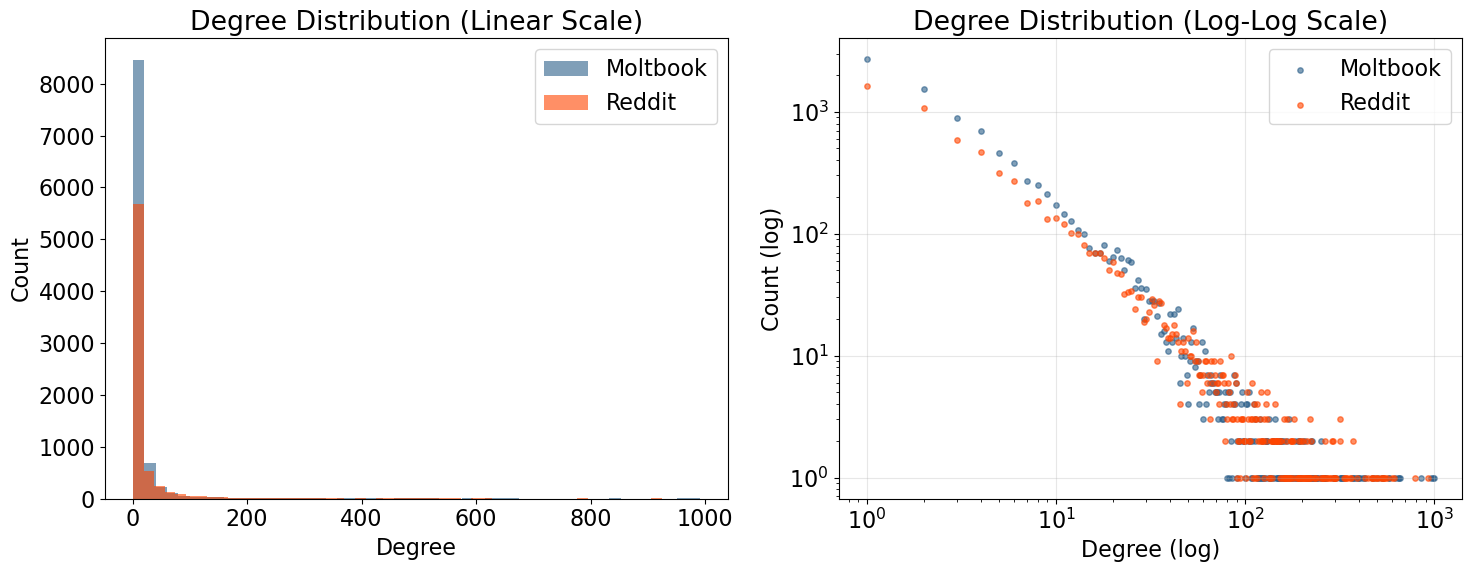

In [12]:
def plot_degree_dist(G_m, G_r):
    colors = get_platform_colors()
    
    m_deg = [d for n, d in G_m.degree() if d > 0]
    r_deg = [d for n, d in G_r.degree() if d > 0]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Standard Histogram
    ax1.hist(m_deg, bins=50, alpha=0.6, color=colors['Moltbook'], label='Moltbook')
    ax1.hist(r_deg, bins=50, alpha=0.6, color=colors['Reddit'], label='Reddit')
    ax1.set_title('Degree Distribution (Linear Scale)')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Count')
    ax1.legend()
    
    # Log-Log Plot (better for power-law analysis)
    m_counts = Counter(m_deg)
    r_counts = Counter(r_deg)
    
    ax2.scatter(list(m_counts.keys()), list(m_counts.values()), 
                color=colors['Moltbook'], alpha=0.6, s=15, label='Moltbook')
    ax2.scatter(list(r_counts.keys()), list(r_counts.values()), 
                color=colors['Reddit'], alpha=0.6, s=15, label='Reddit')
    ax2.set_title('Degree Distribution (Log-Log Scale)')
    ax2.set_xlabel('Degree (log)')
    ax2.set_ylabel('Count (log)')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_degree_dist(G_moltbook, G_reddit)

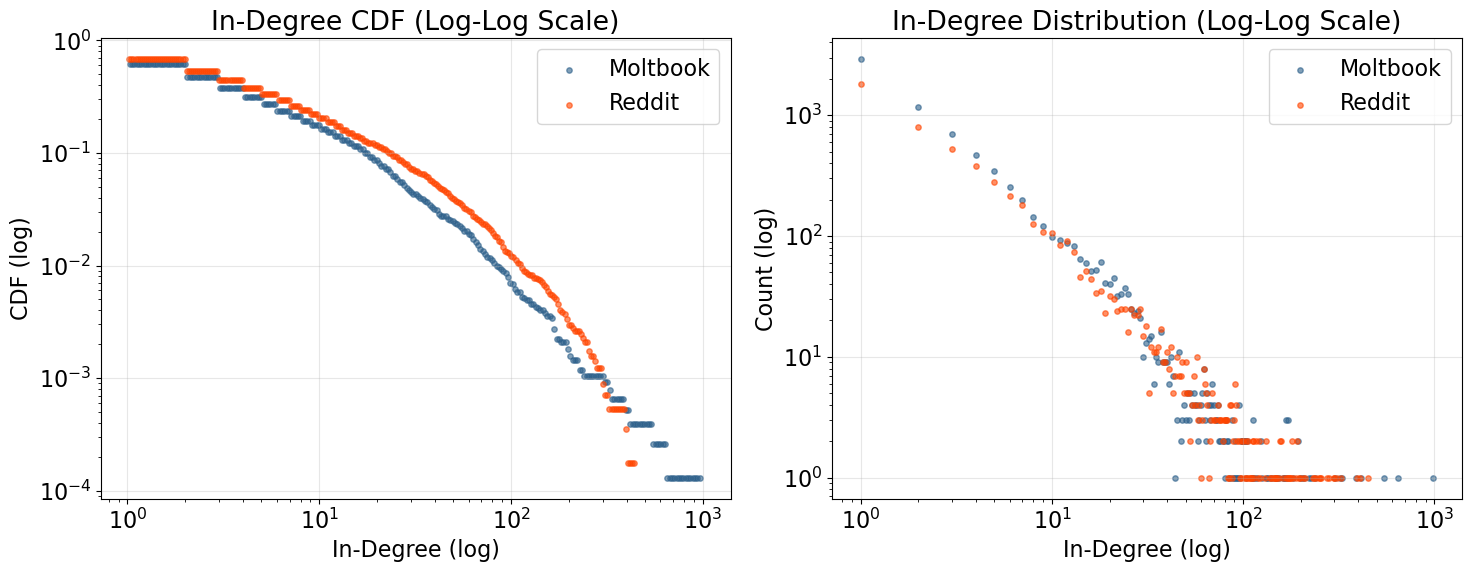

In [13]:
def plot_degree_dist(G_m, G_r):
    colors = get_platform_colors()
    
    m_deg = np.array([d for n, d in G_m.in_degree() if d > 0])
    r_deg = np.array([d for n, d in G_r.in_degree() if d > 0])
    
    # Log-Log Plot (better for power-law analysis)
    m_counts = Counter(m_deg)
    r_counts = Counter(r_deg)

    # get CDF of weighted degree for better visualization
    rm_bins = np.logspace(np.log10(m_deg.min()), np.log10(m_deg.max()), 250)
    rr_bins = np.logspace(np.log10(r_deg.min()), np.log10(r_deg.max()), 250)

    mcounts, mbins = np.histogram(m_deg, bins=rm_bins)
    rcounts, rbins = np.histogram(r_deg, bins=rr_bins)

    mcdf = np.cumsum(mcounts) / sum(mcounts)
    rcdf = np.cumsum(rcounts) / sum(rcounts)
    

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.scatter(mbins[1:], 1 - mcdf, 
                color=colors['Moltbook'], alpha=0.6, s=15, label='Moltbook')
    ax1.scatter(rbins[1:], 1 - rcdf, 
                color=colors['Reddit'], alpha=0.6, s=15, label='Reddit')
    ax1.set_title('In-Degree CDF (Log-Log Scale)')
    ax1.set_xlabel('In-Degree (log)')
    ax1.set_ylabel('CDF (log)')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    
    ax2.scatter(list(m_counts.keys()), list(m_counts.values()), 
                color=colors['Moltbook'], alpha=0.6, s=15, label='Moltbook')
    ax2.scatter(list(r_counts.keys()), list(r_counts.values()), 
                color=colors['Reddit'], alpha=0.6, s=15, label='Reddit')
    ax2.set_title('In-Degree Distribution (Log-Log Scale)')
    ax2.set_xlabel('In-Degree (log)')
    ax2.set_ylabel('Count (log)')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_degree_dist(G_moltbook, G_reddit)

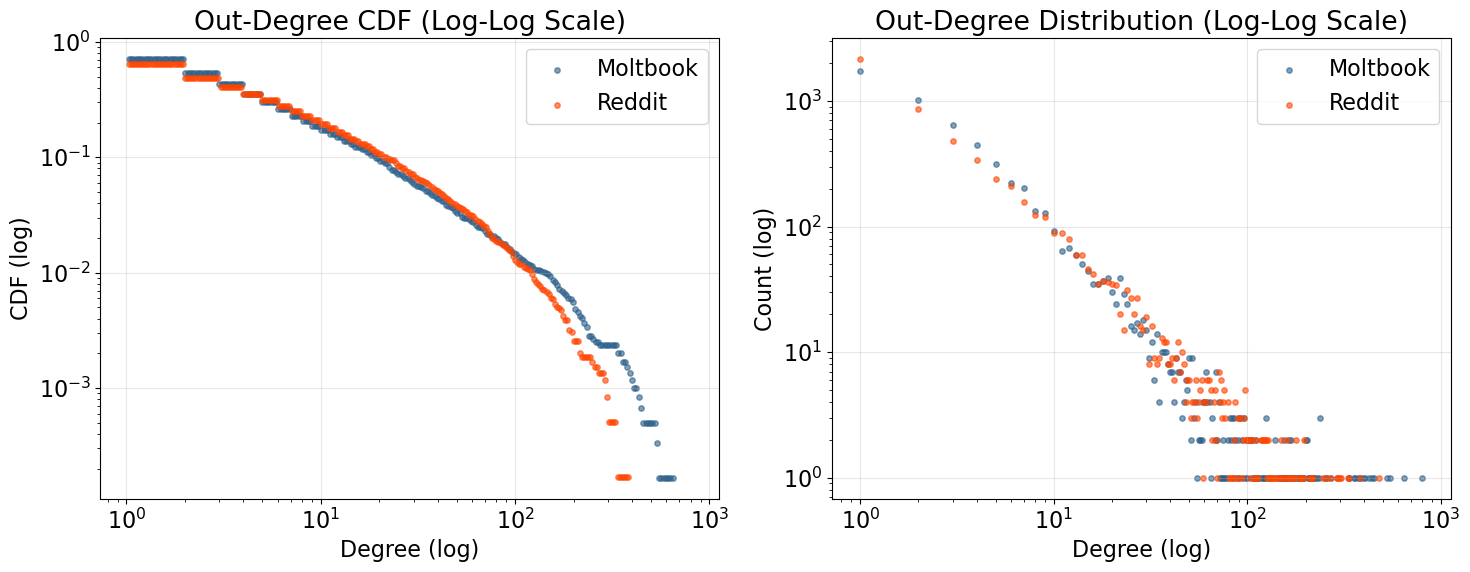

In [14]:
def plot_degree_dist(G_m, G_r):
    colors = get_platform_colors()
    
    m_deg = np.array([d for n, d in G_m.out_degree() if d > 0])
    r_deg = np.array([d for n, d in G_r.out_degree() if d > 0])

    # get CDF of weighted degree for better visualization
    rm_bins = np.logspace(np.log10(m_deg.min()), np.log10(m_deg.max()), 250)
    rr_bins = np.logspace(np.log10(r_deg.min()), np.log10(r_deg.max()), 250)

    mcounts, mbins = np.histogram(m_deg, bins=rm_bins)
    rcounts, rbins = np.histogram(r_deg, bins=rr_bins)

    mcdf = np.cumsum(mcounts) / sum(mcounts)
    rcdf = np.cumsum(rcounts) / sum(rcounts)
    

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Log-Log Plot (better for power-law analysis)
    m_counts = Counter(m_deg)
    r_counts = Counter(r_deg)

    ax1.scatter(mbins[1:], 1 - mcdf, 
                color=colors['Moltbook'], alpha=0.6, s=15, label='Moltbook')
    ax1.scatter(rbins[1:], 1 - rcdf, 
                color=colors['Reddit'], alpha=0.6, s=15, label='Reddit')
    ax1.set_title('Out-Degree CDF (Log-Log Scale)')
    ax1.set_xlabel('Degree (log)')
    ax1.set_ylabel('CDF (log)')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    
    ax2.scatter(list(m_counts.keys()), list(m_counts.values()), 
                color=colors['Moltbook'], alpha=0.6, s=15, label='Moltbook')
    ax2.scatter(list(r_counts.keys()), list(r_counts.values()), 
                color=colors['Reddit'], alpha=0.6, s=15, label='Reddit')
    ax2.set_title('Out-Degree Distribution (Log-Log Scale)')
    ax2.set_xlabel('Degree (log)')
    ax2.set_ylabel('Count (log)')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_degree_dist(G_moltbook, G_reddit)

## 4. Global Graph Level Statistics

Bar chart comparing Assortativity, Avg Clustering, Density, and REciprocity between Moltbook and Reddit.

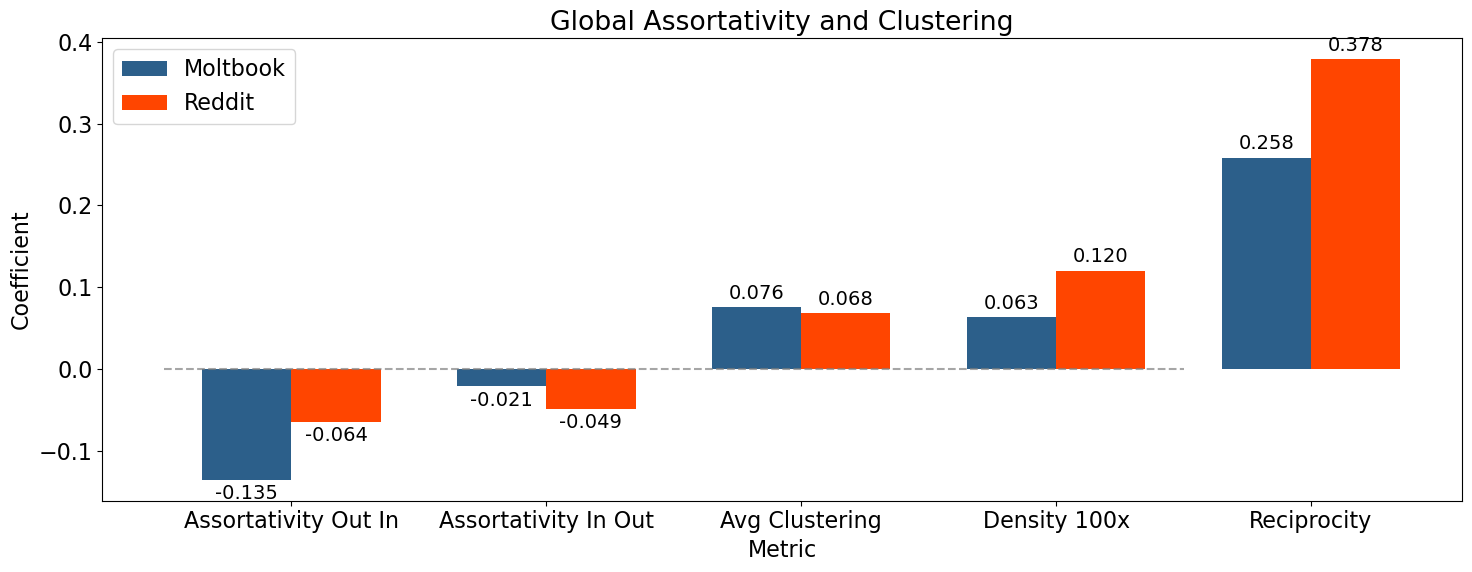

In [15]:
import random

plt.rcParams.update({'font.size': 16})

def plot_assortativity_clustering(G_m, G_r, radius=2):

    # Bar Plot metrics: Assortativity and Average Clustering
    metrics = {
        'Assortativity Out In': {
            'Moltbook': nx.degree_assortativity_coefficient(G_m),
            'Reddit': nx.degree_assortativity_coefficient(G_r)
        },
        'Assortativity In Out': {
            'Moltbook': nx.degree_assortativity_coefficient(G_m, 'in', 'out'),
            'Reddit': nx.degree_assortativity_coefficient(G_r, 'in', 'out')
        },
        'Avg Clustering': {
            'Moltbook': nx.average_clustering(G_m),
            'Reddit': nx.average_clustering(G_r)
        },
        'Density 100x' : {
            'Moltbook': nx.density(G_m) * 100,
            'Reddit': nx.density(G_r) * 100,
        },
        'Reciprocity': {
            'Moltbook': nx.reciprocity(G_m),
            'Reddit': nx.reciprocity(G_r),
        }
    }

    # Clustering distribution
    clust_dist_m = np.array(list(nx.clustering(G_m).values()))
    clust_dist_r = np.array(list(nx.clustering(G_r).values()))
    clust_dist_m = clust_dist_m[clust_dist_m > 0]
    clust_dist_r = clust_dist_r[clust_dist_r > 0]
    # clust_dist_r = clust_dist_r + 1

    colors = get_platform_colors()

    # Generate figure
    fig, (ax1) = plt.subplots(1, 1, figsize=(15, 6))

    x = np.arange(len(metrics))
    width = 0.35
    
    # Put metrics in list for each platform
    m_values = [
                    metrics['Assortativity Out In']['Moltbook'], metrics['Assortativity In Out']['Moltbook'], metrics['Avg Clustering']['Moltbook'], 
                    metrics['Density 100x']['Moltbook'], metrics['Reciprocity']['Moltbook']
                ]
    r_values = [
                    metrics['Assortativity Out In']['Reddit'], metrics['Assortativity In Out']['Reddit'], metrics['Avg Clustering']['Reddit'], 
                    metrics['Density 100x']['Reddit'], metrics['Reciprocity']['Reddit']
                ]

    # plot metrics with bar widths/heights
    rects1 = ax1.bar(x - width/2, m_values, width, label='Moltbook', color=colors['Moltbook'])
    rects2 = ax1.bar(x + width/2, r_values, width, label='Reddit', color=colors['Reddit'])
    ax1.hlines(0, -0.5, 3.5, colors='gray', linestyles='dashed', alpha=0.7)

    # set tick labels to metric names
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics.keys())
    ax1.bar_label(rects1, padding=3, fmt='%.3f', fontsize=14)
    ax1.bar_label(rects2, padding=3, fmt='%.3f', fontsize=14)
    
    ax1.set_title('Global Assortativity and Clustering')
    ax1.set_xlabel('Metric')
    ax1.set_ylabel('Coefficient')
    ax1.legend()

    # # histogram of clustering distribution
    # log_bins = np.logspace(np.log10(min(clust_dist_m)), np.log10(max(clust_dist_m)), num=50)
    # ax2.hist(clust_dist_m, bins=log_bins, alpha=0.5, label='Moltbook', color=colors['Moltbook'], density=True)
    # ax2.hist(clust_dist_r, bins=log_bins, alpha=0.5, label='Reddit', color=colors['Reddit'], density=True)
    # ax2.set_xscale('log')
    # ax2.set_title('Local Clustering Distribution\nCluster = 0 Omitted')
    # ax2.set_xlabel('Local Clustering Coefficient')
    # ax2.set_ylabel('Density')
    # ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_assortativity_clustering(G_moltbook, G_reddit)

# Time Evolution Moltbook Statistics

In [5]:
from utils import load_temporal_moltbook_graph

In [6]:
temporal_mgraphs = load_temporal_moltbook_graph(window_days=3, cache=True)

2026-04-08 10:24:50,573 - INFO - Building Moltbook graph from Hugging Face dataset...


2026-04-08 10:24:50,868 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-04-08 10:24:50,973 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/SimulaMet/moltbook-observatory-archive/4b59a83f0c0f834776e5fe92ccaecd683a6613c1/README.md "HTTP/1.1 200 OK"
2026-04-08 10:24:51,027 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive/resolve/4b59a83f0c0f834776e5fe92ccaecd683a6613c1/moltbook-observatory-archive.py "HTTP/1.1 404 Not Found"
2026-04-08 10:24:51,182 - INFO - HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/SimulaMet/moltbook-observatory-archive/SimulaMet/moltbook-observatory-archive.py "HTTP/1.1 404 Not Found"
2026-04-08 10:24:51,290 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive/resolve/4b59a83f0c0f834776e5fe92c

Cumulative Statistics


c:\Users\malda\anaconda3\envs\moltbook_rf\Lib\site-packages\networkx\algorithms\assortativity\correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


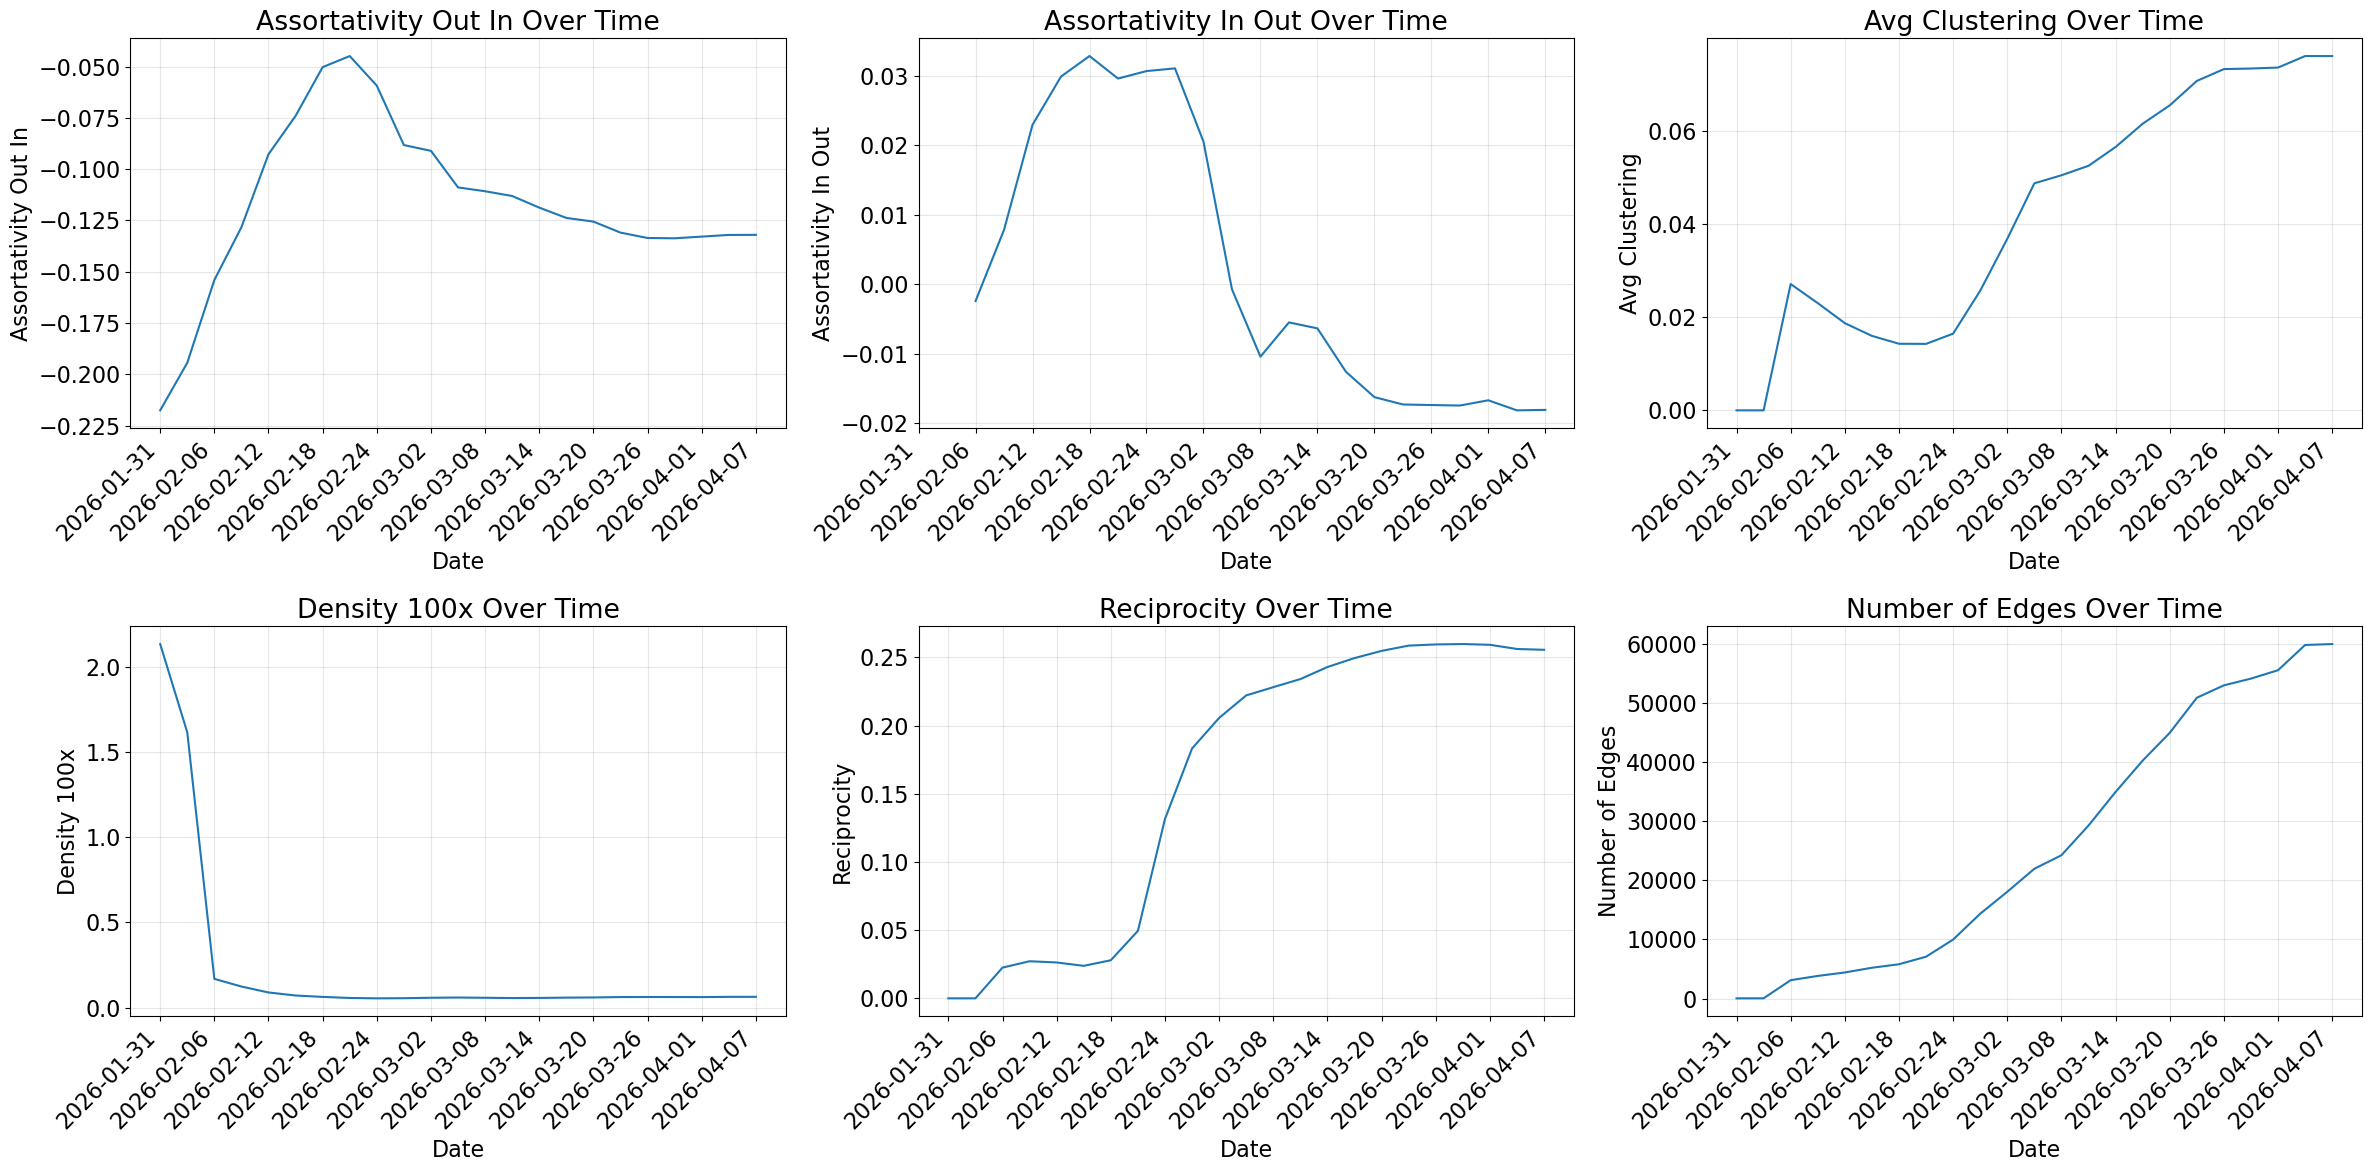

Windowed Statistics


c:\Users\malda\anaconda3\envs\moltbook_rf\Lib\site-packages\networkx\algorithms\assortativity\correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


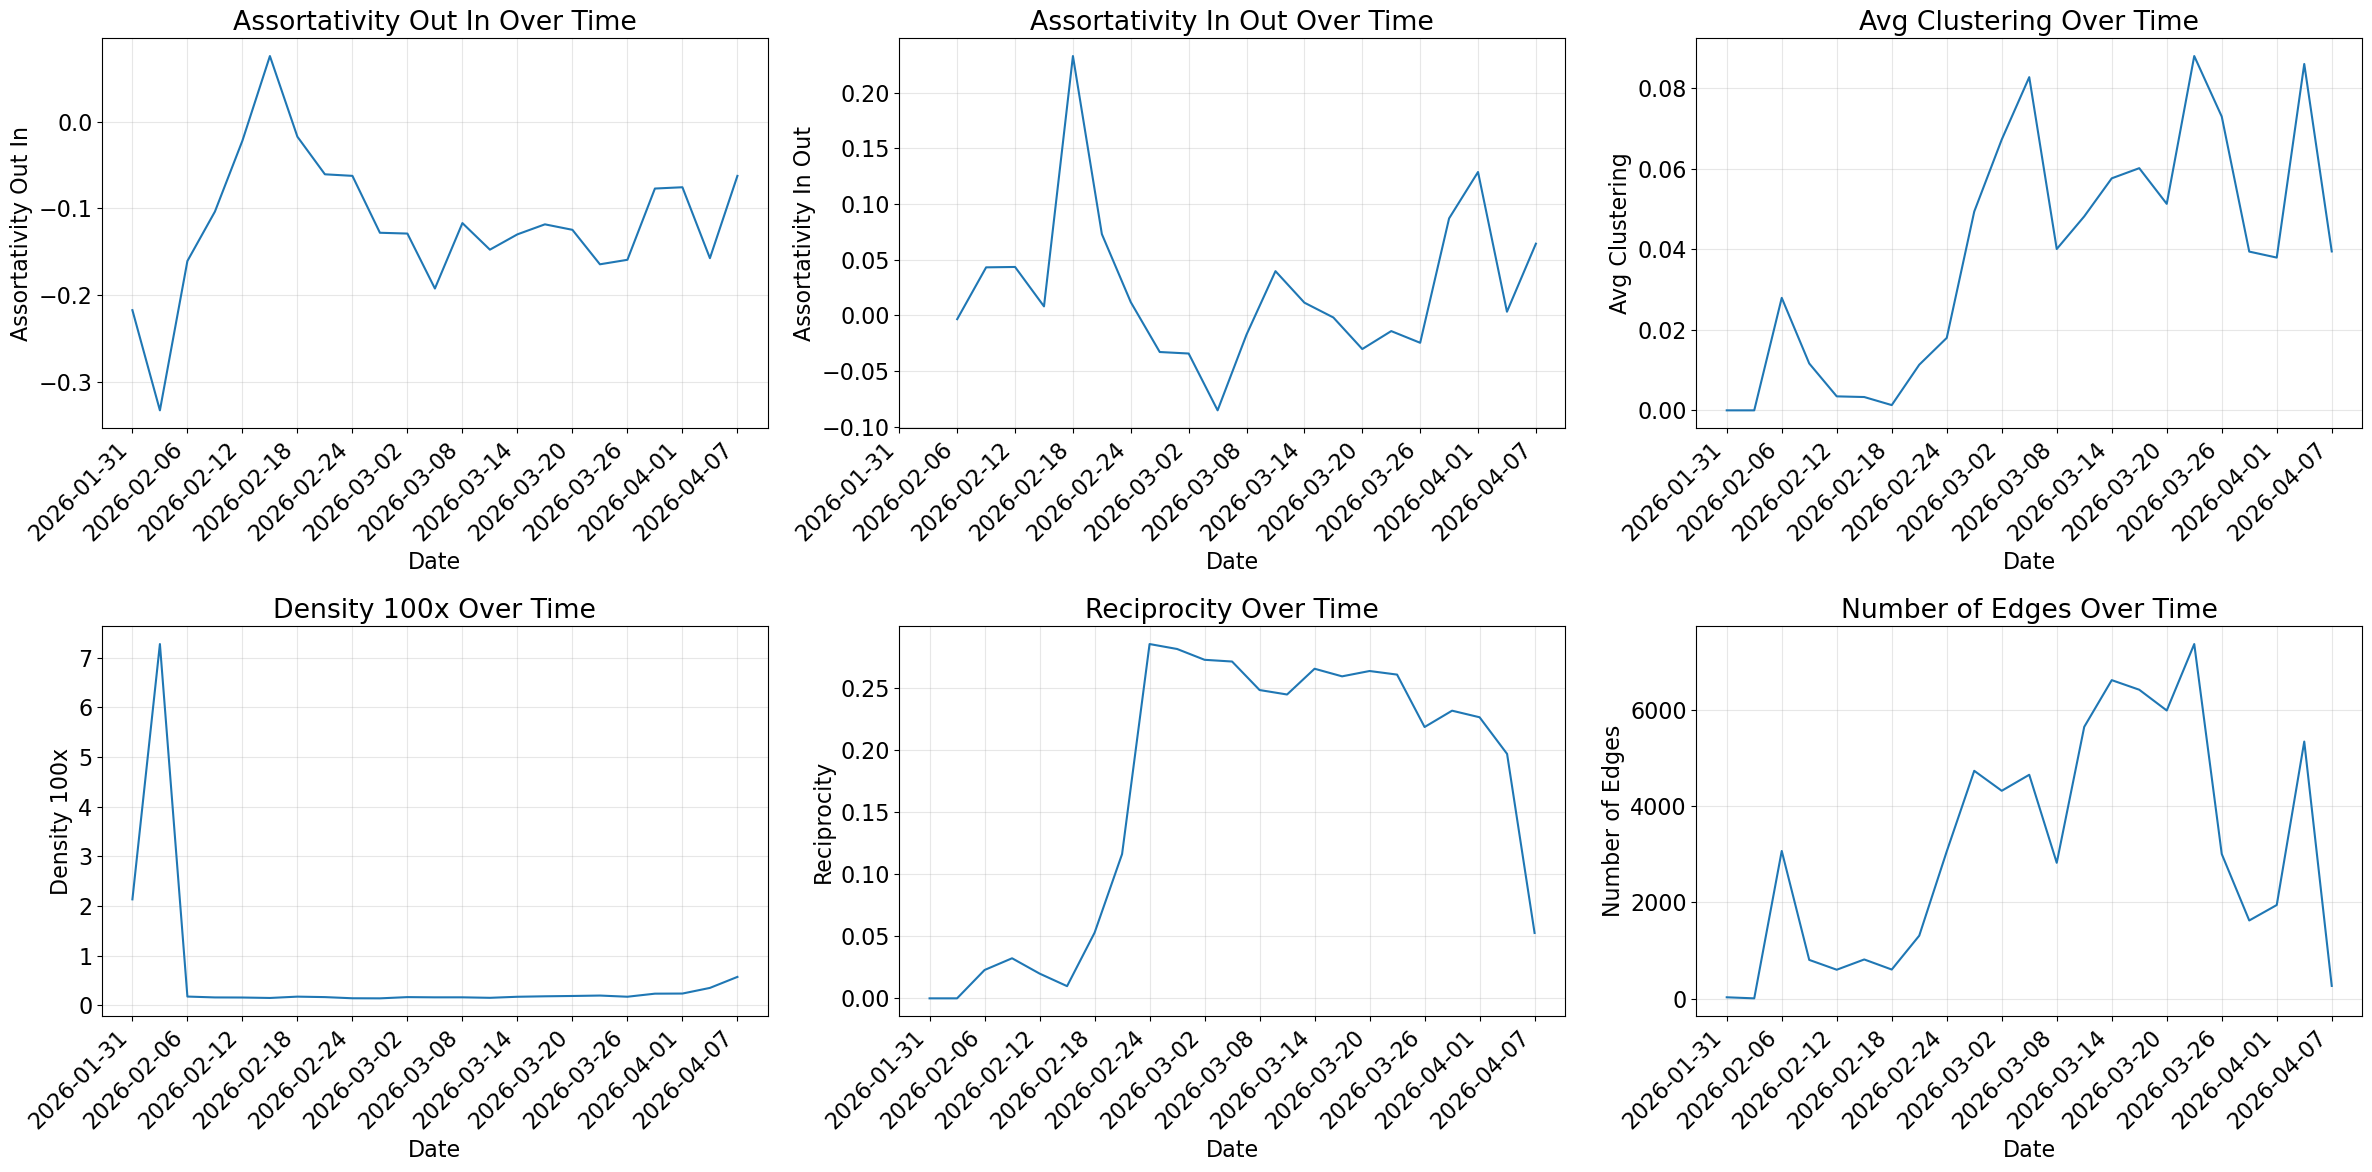

In [ ]:
def plot_time_evolved_stats(time_graphs, window=False):

    # Bar Plot metrics: Assortativity and Average Clustering
    metrics = {
        'Assortativity Out In': [],
        'Assortativity In Out': [],
        'Avg Clustering': [],
        'Density 100x' : [],
        'Reciprocity': [],
        'Number of Edges': []
    }

    graph_key = 'graph_cumulative'
    if window:
        graph_key = 'graph_window'

    time_x = []
    for graph_inst in time_graphs:
        period = graph_inst['date']
        graph = graph_inst[graph_key]
        metrics['Assortativity Out In'].append(nx.degree_assortativity_coefficient(graph, 'out', 'in'))
        metrics['Assortativity In Out'].append(nx.degree_assortativity_coefficient(graph, 'in', 'out'))
        metrics['Avg Clustering'].append(nx.average_clustering(graph))
        metrics['Density 100x'].append(nx.density(graph) * 100)
        metrics['Reciprocity'].append(nx.reciprocity(graph))
        metrics['Number of Edges'].append(graph.number_of_edges())
        time_x.append(period)

    # Generate figure
    fig, axes = plt.subplots(2, 3, figsize=(24, 12))

    for i, metric_key in enumerate(metrics.keys()):
        row = i // 3
        col = i % 3
        ax = axes[row, col]

        ax.plot(time_x, metrics[metric_key])
        
        ax.set_title(f'{metric_key} Over Time')
        ax.set_xlabel('Date')
        ax.set_ylabel(metric_key)
        ax.set_xticks(time_x[::2])
        ax.set_xticklabels([t.strftime('%Y-%m-%d') for t in time_x[::2]], rotation=45, ha='right')

        ax.grid(True, alpha=0.3)

    
    plt.tight_layout()
    plt.show()

print('Cumulative Statistics')
plot_time_evolved_stats(time_graphs=temporal_mgraphs, window=False)

print('Windowed Statistics')
plot_time_evolved_stats(time_graphs=temporal_mgraphs, window=True)

Cumulative Degree Distributions


C:\Users\malda\AppData\Local\Temp\ipykernel_62552\3985087004.py:34: RuntimeWarning: divide by zero encountered in log10
  heatmap_out.append(np.log10(out_ccdf))
C:\Users\malda\AppData\Local\Temp\ipykernel_62552\3985087004.py:35: RuntimeWarning: divide by zero encountered in log10
  heatmap_in.append(np.log10(in_ccdf))


-inf -0.20287930156258147
-inf -0.15024768471973096


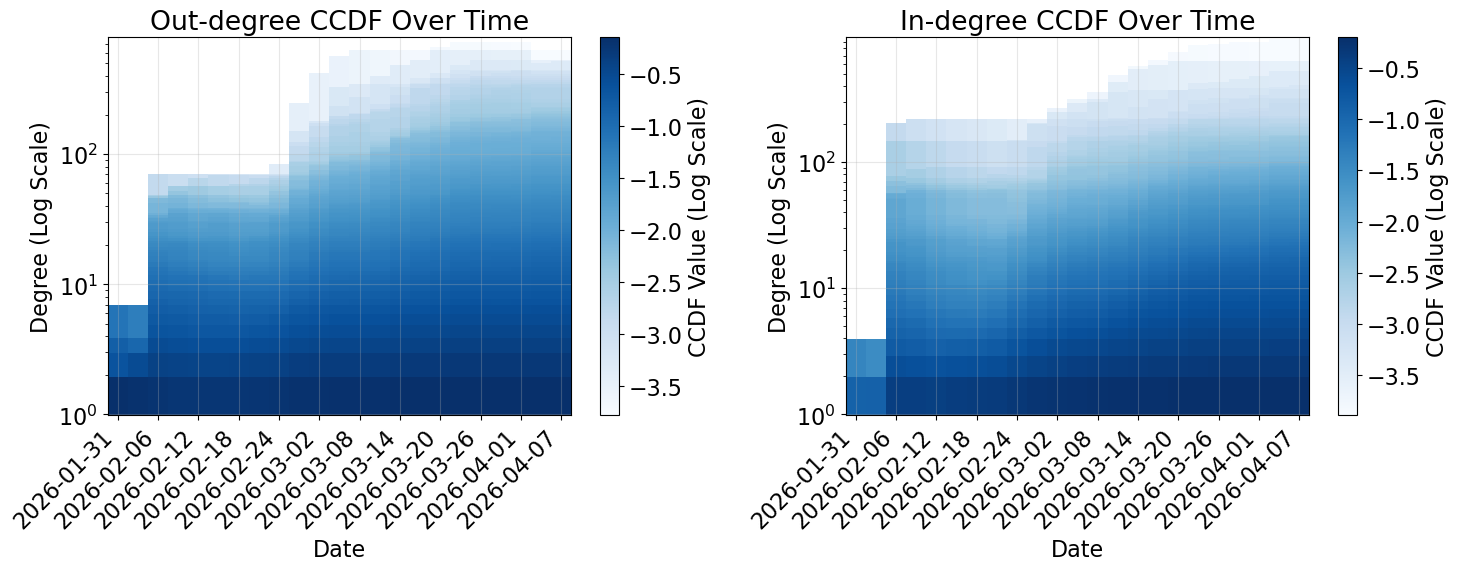

Windowed Degree Distributions
-inf -0.16729667422716163
-inf -0.15281991664269315


C:\Users\malda\AppData\Local\Temp\ipykernel_62552\3985087004.py:34: RuntimeWarning: divide by zero encountered in log10
  heatmap_out.append(np.log10(out_ccdf))
C:\Users\malda\AppData\Local\Temp\ipykernel_62552\3985087004.py:35: RuntimeWarning: divide by zero encountered in log10
  heatmap_in.append(np.log10(in_ccdf))


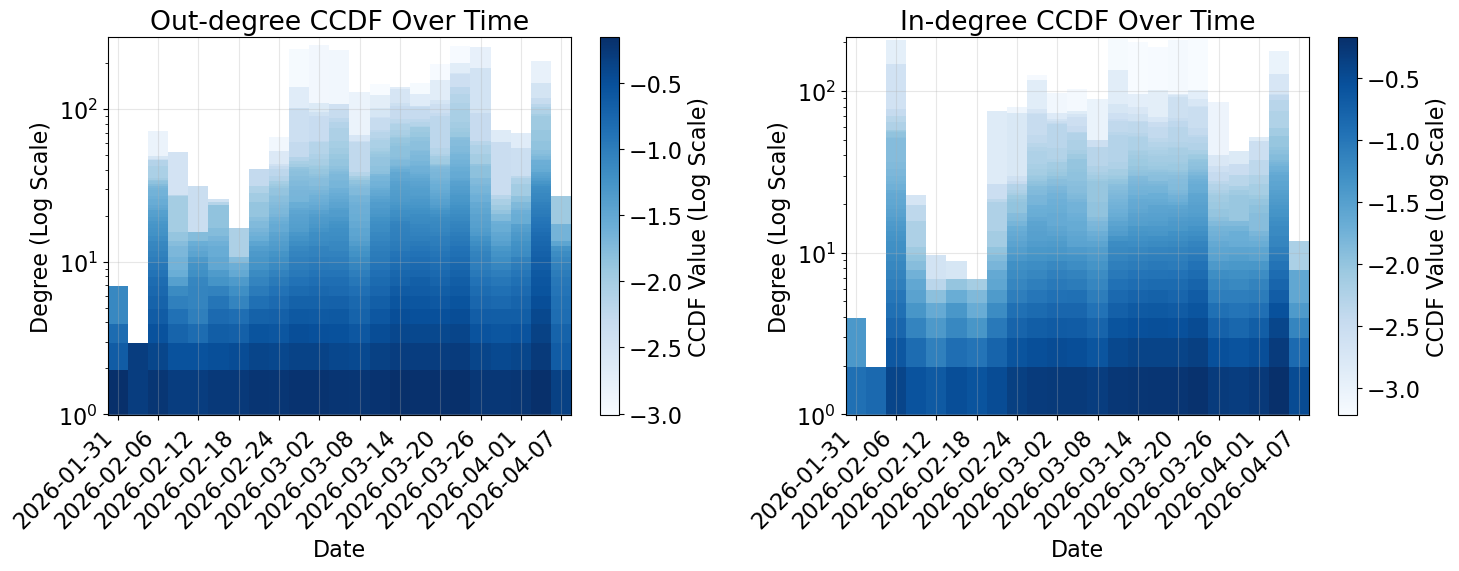

In [12]:
from matplotlib.colors import LogNorm

def plot_time_evolved_degrees(time_graphs, window=False):
    time_x = []
    heatmap_out = []
    heatmap_in = []

    graph_key = 'graph_cumulative'
    if window:
        graph_key = 'graph_window'

    global_out_max = max([max([d for n, d in graph_inst[graph_key].out_degree()] + [1]) for graph_inst in time_graphs])
    global_in_max = max([max([d for n, d in graph_inst[graph_key].in_degree()] + [1]) for graph_inst in time_graphs])

    out_bins = np.logspace(0, np.log10(global_out_max), 300)
    in_bins = np.logspace(0, np.log10(global_in_max), 300)

    for graph_inst in time_graphs:
        period = graph_inst['date']
        graph = graph_inst[graph_key]

        out_deg = np.array([d for n, d in graph.out_degree() if d > 0])
        in_deg = np.array([d for n, d in graph.in_degree() if d > 0])

        out_counts, _ = np.histogram(out_deg, bins=out_bins)
        in_counts, _ = np.histogram(in_deg, bins=in_bins)

        out_cdf = np.cumsum(out_counts) / sum(out_counts)
        in_cdf = np.cumsum(in_counts) / sum(in_counts)

        out_ccdf = 1 - out_cdf
        in_ccdf = 1 - in_cdf

        heatmap_out.append(np.log10(out_ccdf))
        heatmap_in.append(np.log10(in_ccdf))

        time_x.append(period)

    heatmap_out = np.array(heatmap_out).T
    heatmap_in = np.array(heatmap_in).T

    print(heatmap_in.min(), heatmap_in.max())
    print(heatmap_out.min(), heatmap_out.max())

    # Generate figure
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    ax = axes[0]

    pcm = ax.pcolormesh(time_x, out_bins[:-1], heatmap_out, cmap='Blues')

    ax.set_title(f'Out-degree CCDF Over Time')
    ax.set_xlabel('Date')
    ax.set_ylabel('Degree (Log Scale)')

    ax.set_yscale('log')
    fig.colorbar(pcm, ax=ax, label='CCDF Value (Log Scale)')

    ax.set_xticks(time_x[::2])
    ax.set_xticklabels([t.strftime('%Y-%m-%d') for t in time_x[::2]], rotation=45, ha='right')

    ax.grid(True, alpha=0.3)


    ax = axes[1]

    pcm = ax.pcolormesh(time_x, in_bins[:-1], heatmap_in, cmap='Blues')

    ax.set_title(f'In-degree CCDF Over Time')
    ax.set_xlabel('Date')
    ax.set_ylabel('Degree (Log Scale)')

    ax.set_yscale('log')

    ax.set_xticks(time_x[::2])
    ax.set_xticklabels([t.strftime('%Y-%m-%d') for t in time_x[::2]], rotation=45, ha='right')

    ax.grid(True, alpha=0.3)

    fig.colorbar(pcm, ax=ax, label='CCDF Value (Log Scale)')

    plt.tight_layout()
    plt.show()

print('Cumulative Degree Distributions')
plot_time_evolved_degrees(time_graphs=temporal_mgraphs, window=False)

print('Windowed Degree Distributions')
plot_time_evolved_degrees(time_graphs=temporal_mgraphs, window=True)

# GNN on High Interactors

## Define Target Metrics

In [42]:
def extract_target_metrics(time_periods, t_index):
    """
    Given the time_periods array and a current time index t,
    calculates the target labels based on the graph at t + 1.
    """
    if t_index + 1 >= len(time_periods):
        raise ValueError("Cannot extract targets for the final time period (no future data).")
        
    # We look at the isolated activity in the NEXT time window
    future_window_graph = time_periods[t_index + 1]["graph_window"]
    
    # Get all nodes present in the cumulative graph up to time t
    # (These are the users our GNN will be making predictions on)
    current_nodes = list(time_periods[t_index]["graph_cumulative"].nodes())
    
    metrics = []
    
    # Calculate PageRank for the future window (Structural Metric)
    # We use a try-except in case the graph is entirely disconnected
    try:
        pagerank_scores = nx.pagerank(future_window_graph, weight='weight')
    except:
        pagerank_scores = {}

    cnt = 0
    for node in current_nodes:
        if future_window_graph.has_node(node):
            cnt += 1
        # 1. Volume: Total comments sent in the next window (Weighted Out-Degree)
        volume = future_window_graph.out_degree(node, weight='weight') if future_window_graph.has_node(node) else 0
        
        # 2. Breadth: Unique users replied to in the next window (Unweighted Out-Degree)
        breadth = future_window_graph.out_degree(node) if future_window_graph.has_node(node) else 0
        
        # 3. Structural: PageRank in the next window
        structural_pr = pagerank_scores.get(node, 0.0)
        
        metrics.append({
            "node_id": node,
            "target_volume": volume,
            "target_breadth": breadth,
            "target_structural": structural_pr
        })

    print(f'Total Nodes: {len(current_nodes)}\nNodes with Future Activity: {cnt}')
        
    df_targets = pd.DataFrame(metrics)
    
    # Optional: Convert these continuous metrics into binary classifications (e.g., Top 10%)
    for col in ["target_volume", "target_breadth", "target_structural"]:
        threshold = df_targets[col].quantile(0.90)
        # If the threshold is 0 (lots of inactive users), require at least 1 interaction
        threshold = max(threshold, 0.0001) 
        df_targets[f"{col}_is_high"] = (df_targets[col] >= threshold).astype(int)
        
    return df_targets

df_targets = extract_target_metrics(temporal_mgraphs, t_index=15)

Total Nodes: 8256
Nodes with Future Activity: 1388


In [43]:
df_targets

,node_id,target_volume,target_breadth,target_structural,target_volume_is_high,target_breadth_is_high,target_structural_is_high
0,000610fc-2768-4acb-a80c-84167436b001,0,0,0.000000,0,0,0
1,1488cd39-eecc-4a41-97cf-cea0db79083f,0,0,0.000000,0,0,0
2,54be2d5e-4049-4841-a842-fe3acf950fc5,0,0,0.000000,0,0,0
3,5d6d41c7-68d7-410a-b8d8-0f198059d231,0,0,0.000288,0,0,0
4,85b66936-c475-4ac0-8516-995fd6eb54bc,0,0,0.000000,0,0,0
...,...,...,...,...,...,...,...
8251,a73e6cf8-5f73-430f-8de1-4f0360153240,0,0,0.000000,0,0,0
8252,f65d6e0c-6764-4dc3-ac64-685105e2c452,0,0,0.000000,0,0,0
8253,52dd4a13-762f-49f6-9804-bd5c437a26c4,0,0,0.000000,0,0,0
8254,ffe125a6-5921-4c0b-aaa1-6ac63c479ec3,0,0,0.000000,0,0,0


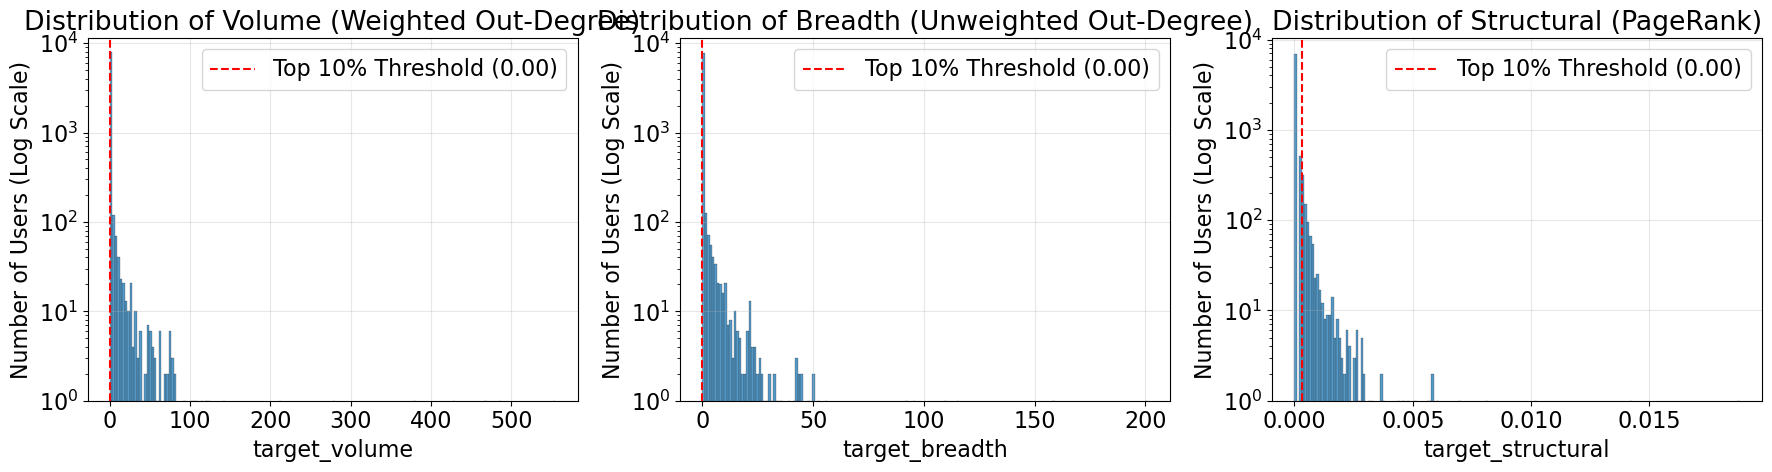

In [44]:
import seaborn as sns

def plot_metric_distributions(df_targets):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    metrics = ['target_volume', 'target_breadth', 'target_structural']
    titles = ['Volume (Weighted Out-Degree)', 'Breadth (Unweighted Out-Degree)', 'Structural (PageRank)']
    
    for i, metric in enumerate(metrics):
        # We use a log scale because network metrics are heavily skewed
        sns.histplot(data=df_targets, x=metric, bins="auto", ax=axes[i])
        axes[i].set_yscale('log')
        axes[i].set_title(f'Distribution of {titles[i]}')
        axes[i].set_ylabel('Number of Users (Log Scale)')
        
        # Draw a vertical line showing where the 90th percentile threshold sits
        threshold = df_targets[metric].quantile(0.90)
        axes[i].axvline(threshold, color='red', linestyle='--', label=f'Top 10% Threshold ({threshold:.2f})')
        axes[i].legend()
        axes[i].set_ylim(1, df_targets[metric].value_counts().max() * 1.5)  # Set y-limit for better visualization
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Usage:
plot_metric_distributions(df_targets)

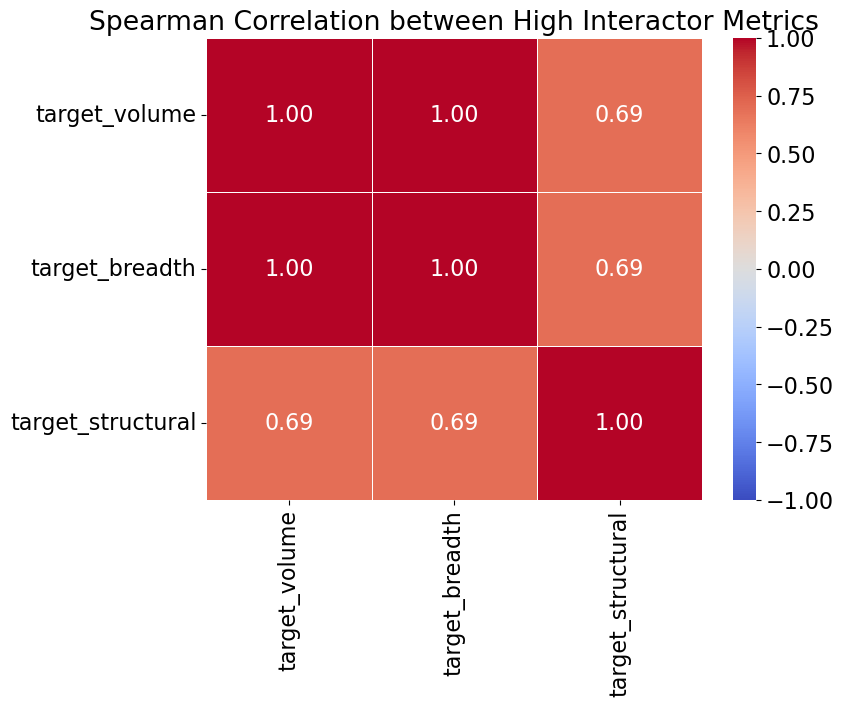

In [45]:
def plot_correlation_matrix(df_targets):
    plt.figure(figsize=(8, 6))
    
    # Isolate the continuous metrics
    metrics_df = df_targets[['target_volume', 'target_breadth', 'target_structural']]
    
    # Calculate the correlation matrix (Spearman is often better for skewed network data)
    corr_matrix = metrics_df.corr(method='spearman')
    
    # Generate a heatmap
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
    plt.title('Spearman Correlation between High Interactor Metrics')
    plt.show()

# Usage:
plot_correlation_matrix(df_targets)